In [3]:
import sys
sys.path.append('../')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shap
from xgboost import XGBClassifier
from src.core.preprocessor import prepare_give_me_some_credit_grandmaster

plt.style.use('seaborn-v0_8-darkgrid')

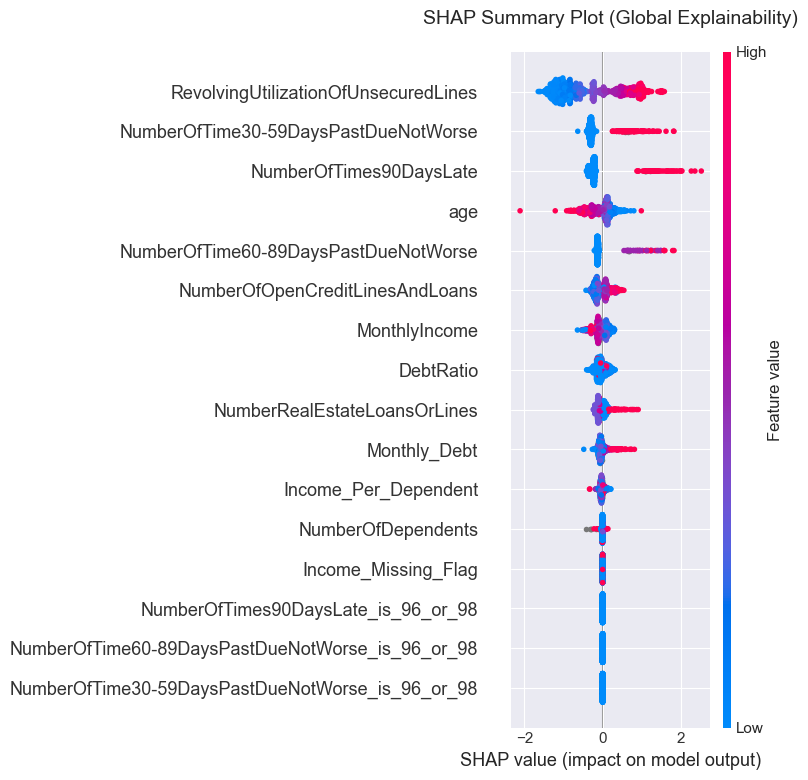

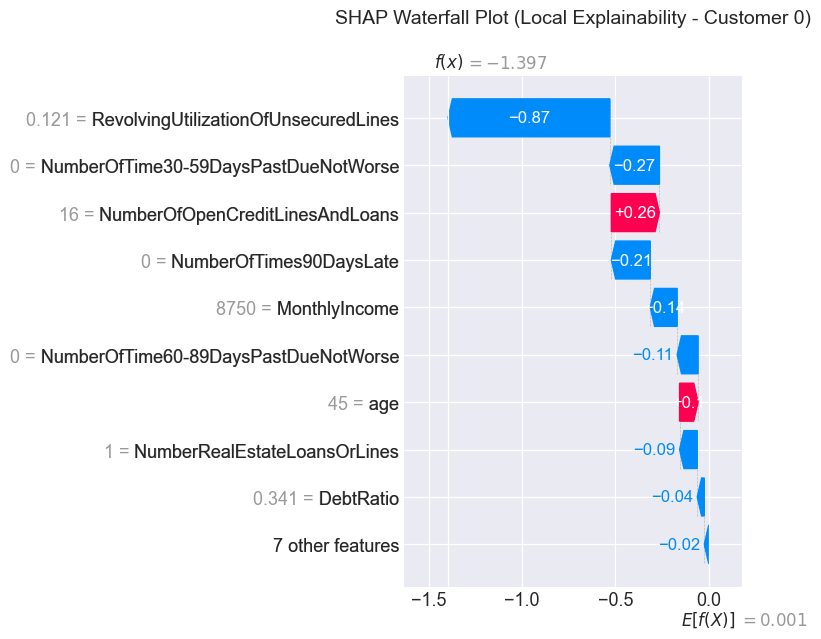

In [4]:
file_path = '../data/raw/Give Me Some Credit/cs-training.csv'
X_train, X_test, y_train, y_test, feature_names = prepare_give_me_some_credit_grandmaster(file_path)

imbalance_ratio = (len(y_train) - sum(y_train)) / sum(y_train)

xgb_gm = XGBClassifier(
    random_state=42,
    eval_metric='logloss',
    scale_pos_weight=imbalance_ratio,
    max_depth=4,
    learning_rate=0.05,
    n_estimators=300,
    n_jobs=-1
)
xgb_gm.fit(X_train, y_train)

X_test_df = pd.DataFrame(X_test, columns=feature_names)
X_test_sample = X_test_df.sample(n=1000, random_state=42)

explainer = shap.TreeExplainer(xgb_gm)
shap_values = explainer(X_test_sample)

plt.figure()
shap.summary_plot(shap_values, X_test_sample, show=False)
plt.title('SHAP Summary Plot (Global Explainability)', pad=20, fontsize=14)
plt.tight_layout()
plt.savefig("shap_summary", dpi=300, bbox_inches="tight")
plt.show()

sample_idx = 0
plt.figure()
shap.plots.waterfall(shap_values[sample_idx], max_display=10, show=False)
plt.title(f'SHAP Waterfall Plot (Local Explainability - Customer {sample_idx})', pad=20, fontsize=14)
plt.tight_layout()
plt.savefig("shap_waterfall", dpi=300, bbox_inches="tight")
plt.show()

<Figure size 1000x600 with 0 Axes>

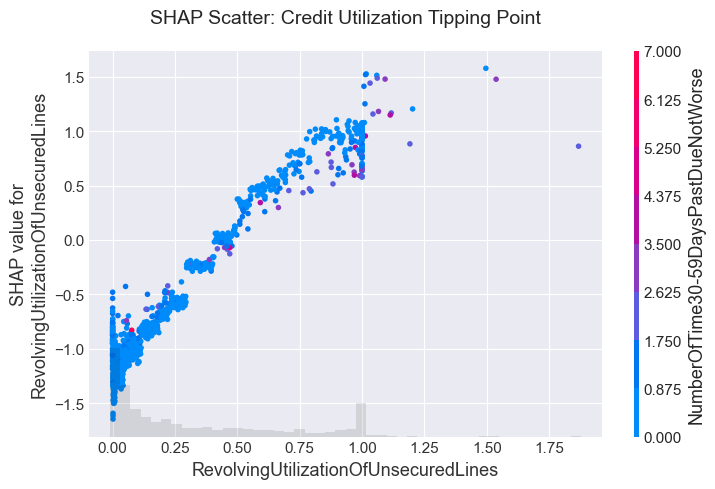

In [5]:
plt.figure(figsize=(10, 6))
shap.plots.scatter(
    shap_values[:, "RevolvingUtilizationOfUnsecuredLines"], 
    color=shap_values[:, "NumberOfTime30-59DaysPastDueNotWorse"], 
    show=False
)
plt.title('SHAP Scatter: Credit Utilization Tipping Point', pad=20, fontsize=14)
plt.tight_layout()
plt.savefig("shap_scatter", dpi=300, bbox_inches="tight")
plt.show()

In [6]:
customer_idx = 0
base_customer = X_test_sample.iloc[[customer_idx]].copy()
base_prob = xgb_gm.predict_proba(base_customer)[0, 1]

best_threshold = 0.7855

simulations = [0.1, 0.3, 0.5, 0.7, 0.9, 1.0, 1.2]
results = []

for util_val in simulations:
    simulated_customer = base_customer.copy()
    simulated_customer['RevolvingUtilizationOfUnsecuredLines'] = util_val
    sim_prob = xgb_gm.predict_proba(simulated_customer)[0, 1]
    
    status = "REJECT" if sim_prob >= best_threshold else "APPROVE"
    
    results.append({
        'Utilisasi_Skenario': f"{util_val*100}%",
        'Probabilitas_Macet': sim_prob,
        'Lonjakan_Risiko': sim_prob - base_prob,
        'Rekomendasi_Sistem': status
    })

df_what_if = pd.DataFrame(results)

print(f"--- COUNTERFACTUAL WHAT-IF ENGINE (Nasabah ID: {customer_idx}) ---")
print(f"Ambang Batas (Threshold) Persetujuan: {best_threshold:.4f}")
print(f"Kondisi Asli (Utilisasi {base_customer['RevolvingUtilizationOfUnsecuredLines'].values[0]*100:.1f}%): Prob {base_prob:.4f}\n")
display(df_what_if)

--- COUNTERFACTUAL WHAT-IF ENGINE (Nasabah ID: 0) ---
Ambang Batas (Threshold) Persetujuan: 0.7855
Kondisi Asli (Utilisasi 12.1%): Prob 0.1983



,Utilisasi_Skenario,Probabilitas_Macet,Lonjakan_Risiko,Rekomendasi_Sistem
0,10.0%,0.174250,-0.024003,APPROVE
1,30.0%,0.312286,0.114033,APPROVE
2,50.0%,0.428179,0.229926,APPROVE
3,70.0%,0.521238,0.322985,APPROVE
4,90.0%,0.588146,0.389893,APPROVE
5,100.0%,0.563523,0.365270,APPROVE
6,120.0%,0.681556,0.483303,APPROVE
